### Assignment-11 Decision Tree

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
xls = pd.ExcelFile("Data\heart_disease.xlsx")

print(xls.sheet_names)

['Description', 'Heart_disease']


In [3]:
data = pd.read_excel("heart_disease.xlsx", sheet_name=1)
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [4]:
data.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

In [5]:
data.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
count,908.000000,908,908,908.000000,908.000000,908,908,908.000000,908,846.000000,908,908,908.000000
unique,NaN,2,4,NaN,NaN,2,3,NaN,4,NaN,3,3,NaN
top,NaN,Male,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,reversable defect,NaN
freq,NaN,718,495,NaN,NaN,723,542,NaN,516,NaN,453,372,NaN
mean,53.791850,NaN,NaN,133.430617,201.484581,NaN,NaN,135.957048,NaN,0.891253,NaN,NaN,1.008811
std,9.158031,NaN,NaN,20.401608,112.097949,NaN,NaN,26.804929,NaN,1.093875,NaN,NaN,1.144436
min,29.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,NaN,0.000000
25%,47.750000,NaN,NaN,120.000000,176.750000,NaN,NaN,118.000000,NaN,0.000000,NaN,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,224.000000,NaN,NaN,138.000000,NaN,0.500000,NaN,NaN,1.000000
75%,60.000000,NaN,NaN,144.000000,270.000000,NaN,NaN,156.000000,NaN,1.500000,NaN,NaN,2.000000


In [6]:
# checking missing values
data.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [7]:
# for numerical cols
data.fillna(data.mean(numeric_only=True), inplace=True)  

In [8]:
# categorical cols
for col in data.select_dtypes(include='object').columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

C:\Users\javee\AppData\Local\Temp\ipykernel_20556\3886909731.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [10]:
data.duplicated().sum()

np.int64(1)

In [11]:
data.drop_duplicates(inplace=True)

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

for col in cat_cols:
    data[col] = data[col].astype(str)   # Convert all values to string
    data[col] = le.fit_transform(data[col])

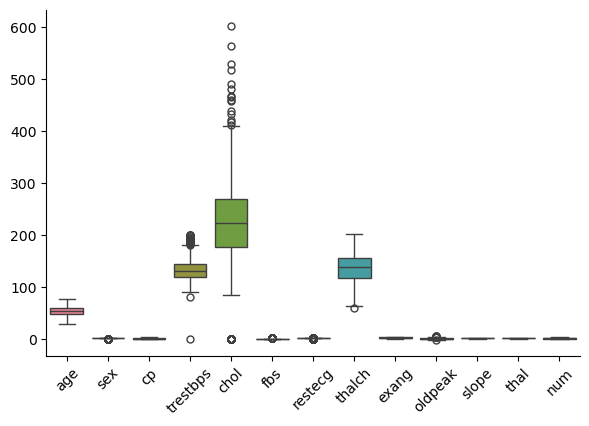

In [13]:
# checking outliers

sns.catplot(data,
           kind='box',
           height=4,
           aspect=1.5,
           )
plt.xticks(rotation=45)
plt.show()


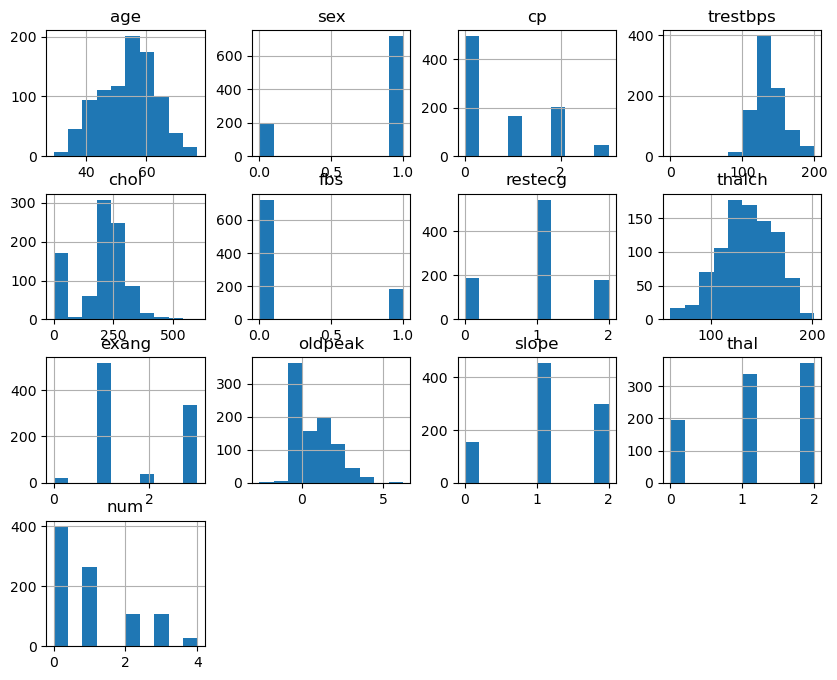

In [14]:
# Histograms

data.hist(figsize=(10,8))
plt.show()

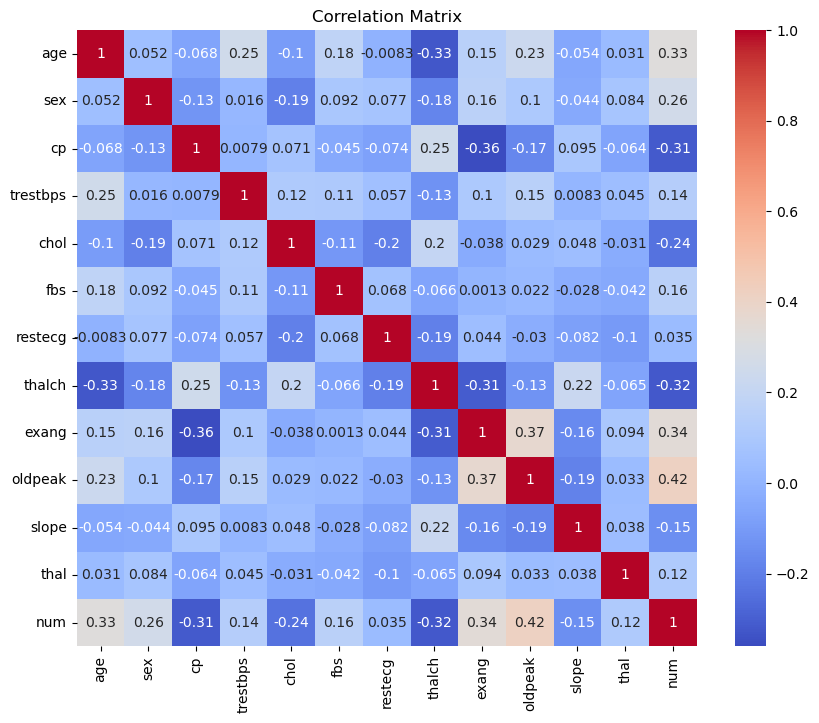

In [15]:
# heatmap

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),
           annot=True,
           cmap='coolwarm'
           )
plt.title('Correlation Matrix')
plt.show()

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
from sklearn.tree import DecisionTreeClassifier

In [55]:
X = data.iloc[:, :-1]   # all columns except last
y = data.iloc[:, -1]    # last column only

In [56]:
# y = (y > 0).astype(int)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((725, 12), (725,), (182, 12), (182,))

In [64]:
# print(X_train.shape)
# print(y_train.shape)
# print(type(y_train))

(725, 12)
(725,)
<class 'pandas.core.series.Series'>


In [65]:
dtree = DecisionTreeClassifier(random_state=42)

dtree.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Evaluate the model on training data

In [67]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [68]:
yhat_train = dtree.predict(X_train)

In [69]:
cm = confusion_matrix(y_train,yhat_train)
cm

array([[310,   0],
       [  0, 415]])

In [70]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       310
           1       1.00      1.00      1.00       415

    accuracy                           1.00       725
   macro avg       1.00      1.00      1.00       725
weighted avg       1.00      1.00      1.00       725



In [71]:
yhat_test = dtree.predict(X_test)

In [72]:
cm = confusion_matrix(y_test,yhat_test)
cm

array([[66, 23],
       [22, 71]])

In [73]:
print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

           0       0.75      0.74      0.75        89
           1       0.76      0.76      0.76        93

    accuracy                           0.75       182
   macro avg       0.75      0.75      0.75       182
weighted avg       0.75      0.75      0.75       182



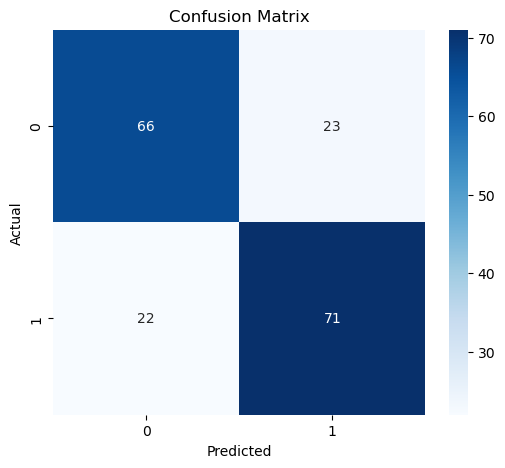

In [74]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [76]:
# ROC-AUC Score
y_prob = dtree.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7525069469614595


#### Hyperparameter Tuning

In [77]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Decision Tree model
dtree = DecisionTreeClassifier(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train GridSearch
grid_search.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best Model
best_model = grid_search.best_estimator_

Best Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [78]:
y_pred = best_model.predict(X_test)

#### Model Evaluation and Analysis

In [94]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_auc_score


In [85]:
print('precision_score:',precision_score(y_test,y_pred))

precision_score: 0.7477477477477478


In [89]:
print('recall_score:',recall_score(y_test,y_pred))

recall_score: 0.8924731182795699


In [90]:
print('f1_score:',f1_score(y_test,y_pred))

f1_score: 0.8137254901960784


In [88]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.69      0.76        89
           1       0.75      0.89      0.81        93

    accuracy                           0.79       182
   macro avg       0.80      0.79      0.79       182
weighted avg       0.80      0.79      0.79       182



In [92]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[61, 28],
       [10, 83]])

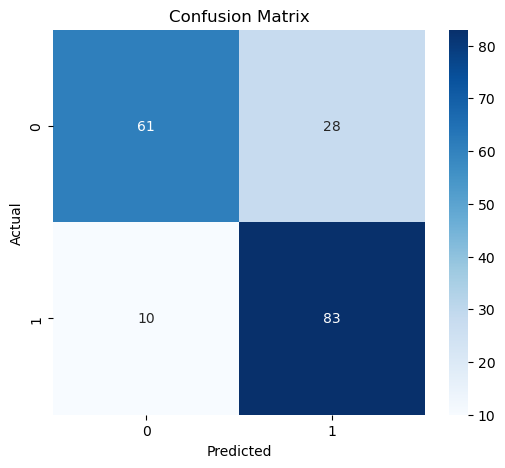

In [91]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [93]:
y_prob = best_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8410051951190045


#### Visualizing Decision Tree

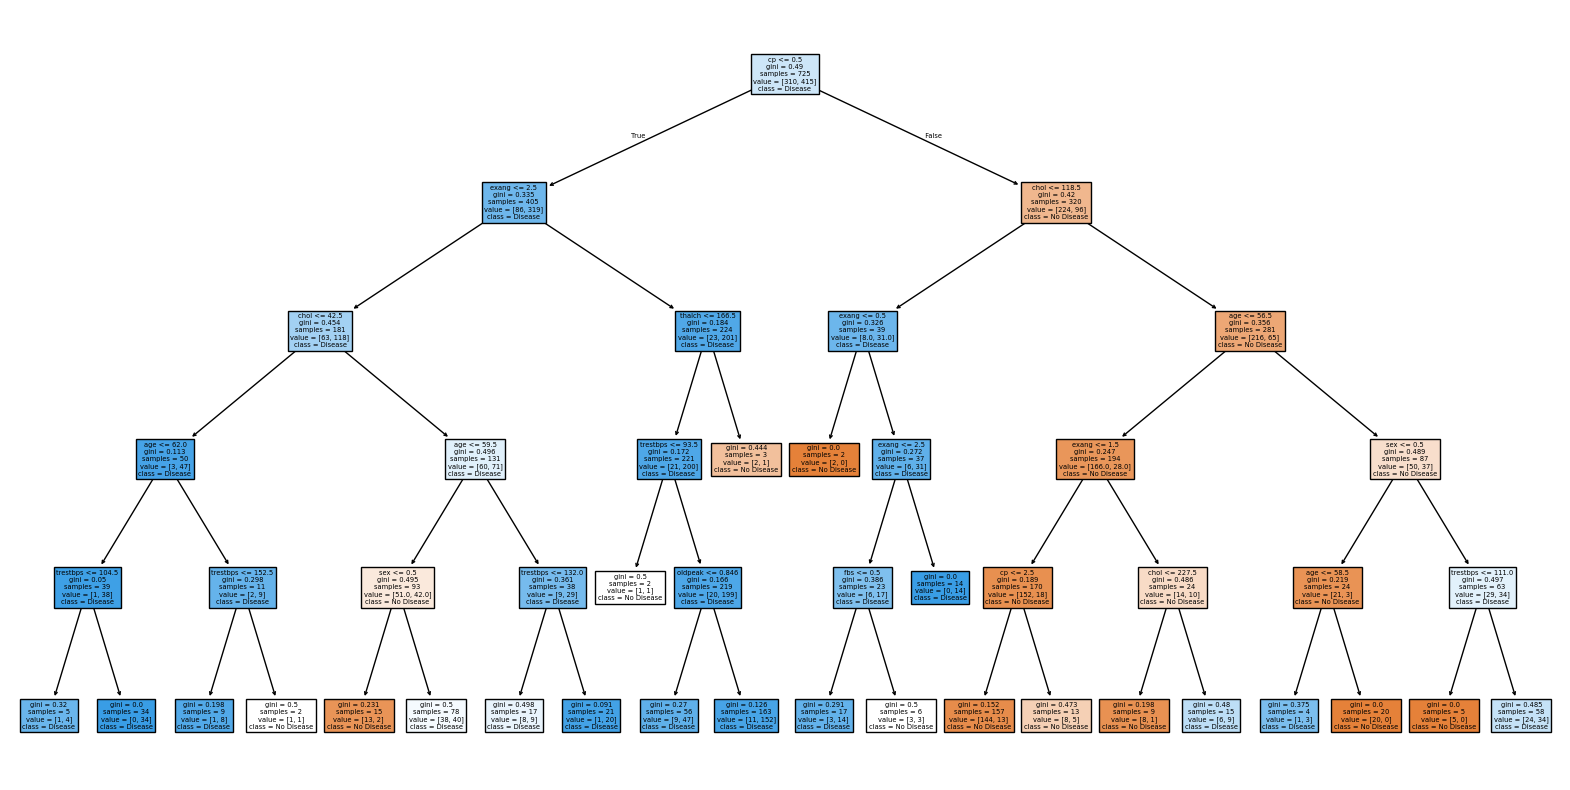

In [95]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'],
    filled=True
)

plt.show()

#### Feature importance

In [96]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

     Feature  Importance
2         cp    0.476051
4       chol    0.196014
8      exang    0.108998
0        age    0.103106
1        sex    0.052408
3   trestbps    0.043839
7     thalch    0.010560
5        fbs    0.005068
9    oldpeak    0.003955
6    restecg    0.000000
10     slope    0.000000
11      thal    0.000000


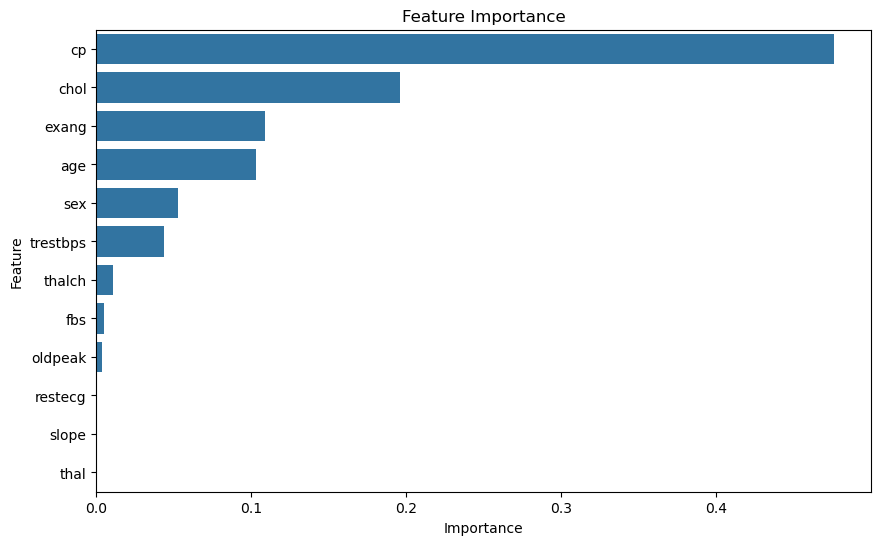

In [97]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

### Interview Questions

#### 1. Common Hyperparameters of Decision Tree Models and Their Effects
Hyperparameters are configuration settings defined before training a machine learning model. In decision tree models, hyperparameters control how the tree grows, splits data, and generalizes to unseen data. Proper tuning of these parameters helps improve accuracy and prevent overfitting or underfitting.
Important Hyperparameters

##### a) max_depth
This parameter specifies the maximum depth of the decision tree.
A larger depth allows the tree to learn more complex patterns.
If the depth is too high, the model may overfit the training data.
A smaller depth creates a simpler tree and reduces overfitting but may lead to underfitting.


##### b) min_samples_split
It defines the minimum number of samples required to split an internal node.
Larger values restrict unnecessary splitting and improve generalization.


##### c) min_samples_leaf
This parameter sets the minimum number of samples required in a leaf node.
Higher values make the model more stable and reduce noise sensitivity.
Lower values may create highly specific rules that overfit the data.


##### d) criterion
The criterion determines how the quality of a split is measured.
Common criteria:
Gini Impurity
Entropy (Information Gain)
Both methods aim to create pure child nodes, but entropy involves logarithmic calculations and is computationally slower.


##### e) max_features
Specifies the maximum number of features considered while searching for the best split.
Reducing features can decrease overfitting.
It also improves model diversity in ensemble methods like Random Forest.


##### f) splitter
Determines how the split at each node is selected.
Types:
best → Chooses the best possible split.
random → Chooses a random split among the best candidates.
Random splitting may improve speed and reduce variance.
Effect on Model Performance
##### Hyperparameters directly influence:
Model complexity
Training time
Accuracy
Bias and variance

A very deep tree generally gives high training accuracy but poor testing accuracy due to overfitting. Proper hyperparameter tuning helps balance bias and variance, resulting in better model performance.

#### 2. Difference Between Label Encoding and One-Hot Encoding

Categorical data cannot be directly used in most machine learning algorithms. Encoding techniques convert categorical values into numerical form. Two common encoding methods are Label Encoding and One-Hot Encoding.


    
#### Label Encoding

Label Encoding converts each category into a unique integer value.

#####  Example
Low    → 0
Medium → 1
High   → 2
##### Characteristics
Uses a single column.
Simple and memory efficient.
Suitable for ordinal data where categories have a meaningful order.
##### Advantages
Easy to implement.
Requires less storage space.
Faster processing.
##### Disadvantages
The model may assume numerical order between categories even when no order exists.
Can reduce model performance for nominal data.
Best Used When
Data is ordinal (e.g., Small, Medium, Large).

#### One-Hot Encoding

One-Hot Encoding creates separate binary columns for each category.

##### Example
Red   → [1,0,0]
Blue  → [0,1,0]
Green → [0,0,1]
##### Characteristics
Creates multiple columns.
No numerical relationship between categories.
Suitable for nominal categorical data.
##### Advantages
Prevents false ordinal relationships.
Improves performance for many machine learning models.
##### Disadvantages
Increases dimensionality when categories are large.
Requires more memory and computation.